# 🧠 Intent Analyzer Agent — Node-by-Node LangGraph Build

This notebook builds and tests the **Intent Analyzer Subgraph** node-by-node from scratch, identical to how `graph_build.ipynb` builds the Merchant graph.

### Architecture of the Subgraph
```text
START ──► [intent_analyzer_node] ──► END
                  │
     ┌────────────┼────────────┐
     ▼            ▼            ▼
 1. Intent    2. Catalog   3. Policy
  Signals      Grounding     Engine
```

### Step 1: Environment & Path Setup

In [1]:
import os
import sys
from pathlib import Path
from dotenv import load_dotenv

# Set backend root path
backend_root = Path.cwd().parents[3] if 'intent_analyzer_llm' in str(Path.cwd()) else Path(r'c:\Users\ps302\OneDrive\Desktop\Razorpay\SpiceBox-Agent-OS\backend')
if str(backend_root) not in sys.path:
    sys.path.insert(0, str(backend_root))

# Load .env
load_dotenv(str(backend_root / '.env'))
WIKI_PATH = str(backend_root / 'merchant_knowledge')

print('Backend root:', backend_root)
print('Wiki Knowledge Path:', WIKI_PATH)


Backend root: c:\Users\ps302\OneDrive\Desktop\Razorpay\SpiceBox-Agent-OS\backend
Wiki Knowledge Path: c:\Users\ps302\OneDrive\Desktop\Razorpay\SpiceBox-Agent-OS\backend\merchant_knowledge


### Step 2: Define State (`IntentAnalysisState`)
Defines the schema flowing through the LangGraph node.

In [2]:
from typing import TypedDict, Annotated, List, Dict, Any, Optional
from langgraph.graph.message import add_messages
from langchain_core.messages import HumanMessage, AIMessage

class IntentAnalysisState(TypedDict, total=False):
    messages: Annotated[List[Any], add_messages]
    wiki_base_path: str
    product_need: Optional[str]
    catalog_context: List[Dict[str, Any]]
    candidate_products: List[Dict[str, Any]]
    stated_budget: Optional[float]
    effective_budget: Optional[float]
    acceptable_budget_stretch: Optional[float]
    budget_restrictiveness: float
    quality_value_orientation: float
    upsell_openness: float
    upsell_opportunity_score: float
    upsell_decision: str
    intent_confidence: float
    intent_evidence: Dict[str, str]
    intent_history: List[Dict[str, Any]]
    questions_asked: int
    recommended_product: Optional[Dict[str, Any]]
    cross_sell_candidates: List[Dict[str, Any]]

print('IntentAnalysisState schema defined successfully with', len(IntentAnalysisState.__annotations__), 'fields.')


IntentAnalysisState schema defined successfully with 19 fields.


### Step 3: Define Structured Pydantic Output (`CustomerIntent`)

In [3]:
from pydantic import BaseModel, Field

class CustomerIntent(BaseModel):
    """Signals inferred from customer conversation, never a product decision."""
    budget_restrictiveness: float = Field(default=0.5, ge=0, le=1)
    quality_value_orientation: float = Field(default=0.5, ge=0, le=1)
    upsell_openness: float = Field(default=0.5, ge=0, le=1)
    confidence: float = Field(default=0.0, ge=0, le=1)
    acceptable_budget_stretch: Optional[float] = Field(default=None, ge=0, le=1)
    stated_budget: Optional[float] = Field(default=None, ge=0)
    hard_budget_constraint: bool = False
    evidence: Dict[str, str] = Field(default_factory=dict)

print('CustomerIntent schema ready.')


CustomerIntent schema ready.


### Step 4: Define Deterministic Policy Functions (`policy.py`)
Pure Python logic that determines scores, boundary caps, and upgrades without LLM hallucination.

In [4]:
def calculate_upsell_score(
    budget_restrictiveness: float,
    quality_value_orientation: float,
    upsell_openness: float,
) -> float:
    score = 100 * (
        0.45 * upsell_openness
        + 0.30 * quality_value_orientation
        + 0.25 * (1 - budget_restrictiveness)
    )
    return round(max(0.0, min(100.0, score)), 2)


def calculate_budget_boundary(
    stated_budget: Optional[float], acceptable_budget_stretch: Optional[float], hard_budget_constraint: bool = False
) -> Optional[float]:
    if stated_budget is None:
        return None
    if hard_budget_constraint:
        return stated_budget
    return round(stated_budget * (1 + (acceptable_budget_stretch or 0.0)), 2)


def decide_upsell(score: float, hard_budget_constraint: bool = False) -> str:
    if hard_budget_constraint or score < 30:
        return 'NO_UPSELL'
    if score < 60:
        return 'SOFT_UPSELL'
    return 'ACTIVE_UPSELL'


def select_upsell_candidate(
    candidates: list,
    stated_budget: Optional[float],
    maximum_acceptable_price: Optional[float],
) -> Optional[dict]:
    normalized = [p for p in candidates if isinstance(p.get('price'), (int, float))]
    normalized.sort(key=lambda p: p['price'])
    if not normalized:
        return None
    baseline = next((p for p in normalized if stated_budget is None or p['price'] <= stated_budget), normalized[0])
    ceiling = maximum_acceptable_price
    for product in normalized:
        if product['price'] <= baseline['price']:
            continue
        if ceiling is not None and product['price'] > ceiling:
            continue
        return product
    return None


def decide_cross_sell(
    primary_selected: bool,
    candidates: list,
    previously_shown: list = (),
    rejected: bool = False,
) -> list:
    if not primary_selected or rejected:
        return []
    shown = set(previously_shown)
    return [p for p in candidates if p.get('id') not in shown][:2]

print('Policy functions defined successfully.')


Policy functions defined successfully.


### Step 5: Define the Node Function (`intent_analyzer_node`)
Integrates signal extraction, real catalog search, and policy calculation.

In [5]:
from src.agents.intent_analyzer_llm.analyzer import _analyze_selling_context

def intent_analyzer_node(state: IntentAnalysisState) -> Dict[str, Any]:
    """
    Main LangGraph node for Intent Analysis and Grounding.
    Returns only state additions, preserving the parent graph contract.
    """
    wiki_path = state.get('wiki_base_path', WIKI_PATH)
    return _analyze_selling_context(state, wiki_path)

print('intent_analyzer_node ready.')


intent_analyzer_node ready.


### Step 6: Build the LangGraph Workflow (`StateGraph`)

Intent Analyzer Subgraph compiled successfully!


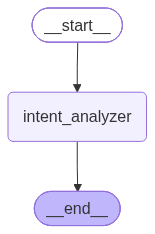

In [11]:
from langgraph.graph import StateGraph, START, END

# 1. Initialize StateGraph with our state schema
graph_builder = StateGraph(IntentAnalysisState)

# 2. Add node
graph_builder.add_node('intent_analyzer', intent_analyzer_node)

# 3. Add edges
graph_builder.add_edge(START, 'intent_analyzer')
graph_builder.add_edge('intent_analyzer', END)

# 4. Compile workflow
intent_graph = graph_builder.compile()

print('Intent Analyzer Subgraph compiled successfully!')
intent_graph


### Step 7: Test Invocations (Node Verification)

#### Test Case 1: Flexible Customer (Willing to Stretch for Quality)

In [7]:
test_state_1 = {
    'messages': [HumanMessage(content='I need a durable watch around Rs 5000 and can stretch Rs 1000 for better quality.')],
    'wiki_base_path': WIKI_PATH,
}

res_1 = intent_graph.invoke(test_state_1)

print('=== TEST 1 RESULT ===')
print('Stated Budget    :', res_1['stated_budget'])
print('Effective Budget :', res_1['effective_budget'])
print('Upsell Score     :', res_1['upsell_opportunity_score'])
print('Upsell Decision  :', res_1['upsell_decision'])
print('Recommended Item :', res_1['recommended_product']['name'] if res_1['recommended_product'] else None)
print('Candidates Found :', len(res_1['candidate_products']))


intent_analyzer_structured_output_unavailable: [WinError 10060] A connection attempt failed because the connected party did not properly respond after a period of time, or established connection failed because connected host has failed to respond


=== TEST 1 RESULT ===
Stated Budget    : 5000.0
Effective Budget : 6000.0
Upsell Score     : 71.25
Upsell Decision  : ACTIVE_UPSELL
Recommended Item : Apex Active Pulse Gps Watch 12
Candidates Found : 5


#### Test Case 2: Strict Budget (Hard Refusal Override)

In [8]:
test_state_2 = {
    'messages': [HumanMessage(content='I want a watch under Rs 4000. Do not show anything above that price, not a single rupee more.')],
    'wiki_base_path': WIKI_PATH,
}

res_2 = intent_graph.invoke(test_state_2)

print('=== TEST 2 RESULT ===')
print('Stated Budget    :', res_2['stated_budget'])
print('Effective Budget :', res_2['effective_budget'])
print('Budget Restrict. :', res_2['budget_restrictiveness'])
print('Upsell Decision  :', res_2['upsell_decision'])  # Must be NO_UPSELL


intent_analyzer_structured_output_unavailable: [WinError 10060] A connection attempt failed because the connected party did not properly respond after a period of time, or established connection failed because connected host has failed to respond


=== TEST 2 RESULT ===
Stated Budget    : 4000.0
Effective Budget : 4000.0
Budget Restrict. : 1.0
Upsell Decision  : NO_UPSELL


#### Test Case 3: Cheapest Possible Product (`NO_UPSELL`)

In [9]:
test_state_3 = {
    'messages': [HumanMessage(content='Show me the cheapest possible phone available around Rs 10000.')],
    'wiki_base_path': WIKI_PATH,
}

res_3 = intent_graph.invoke(test_state_3)

print('=== TEST 3 RESULT ===')
print('Upsell Decision  :', res_3['upsell_decision'])  # Must be NO_UPSELL
print('Upsell Score     :', res_3['upsell_opportunity_score'])


intent_analyzer_structured_output_unavailable: [WinError 10060] A connection attempt failed because the connected party did not properly respond after a period of time, or established connection failed because connected host has failed to respond


=== TEST 3 RESULT ===
Upsell Decision  : NO_UPSELL
Upsell Score     : 8.5


#### Test Case 4: Non-Existent Product (Zero Hallucination)

In [10]:
test_state_4 = {
    'messages': [HumanMessage(content='I want to buy a flying hoverboard rocket jetpack for Rs 50000.')],
    'wiki_base_path': WIKI_PATH,
}

res_4 = intent_graph.invoke(test_state_4)

print('=== TEST 4 RESULT ===')
print('Candidates Count :', len(res_4['candidate_products']))
print('Recommended Item :', res_4['recommended_product'])


intent_analyzer_structured_output_unavailable: [WinError 10060] A connection attempt failed because the connected party did not properly respond after a period of time, or established connection failed because connected host has failed to respond


=== TEST 4 RESULT ===
Candidates Count : 0
Recommended Item : None
